2026-04-08 11:09:50.078386: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 11:09:50.137497: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775617790.188830   20633 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775617790.217761   20633 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-08 11:09:50.304897: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

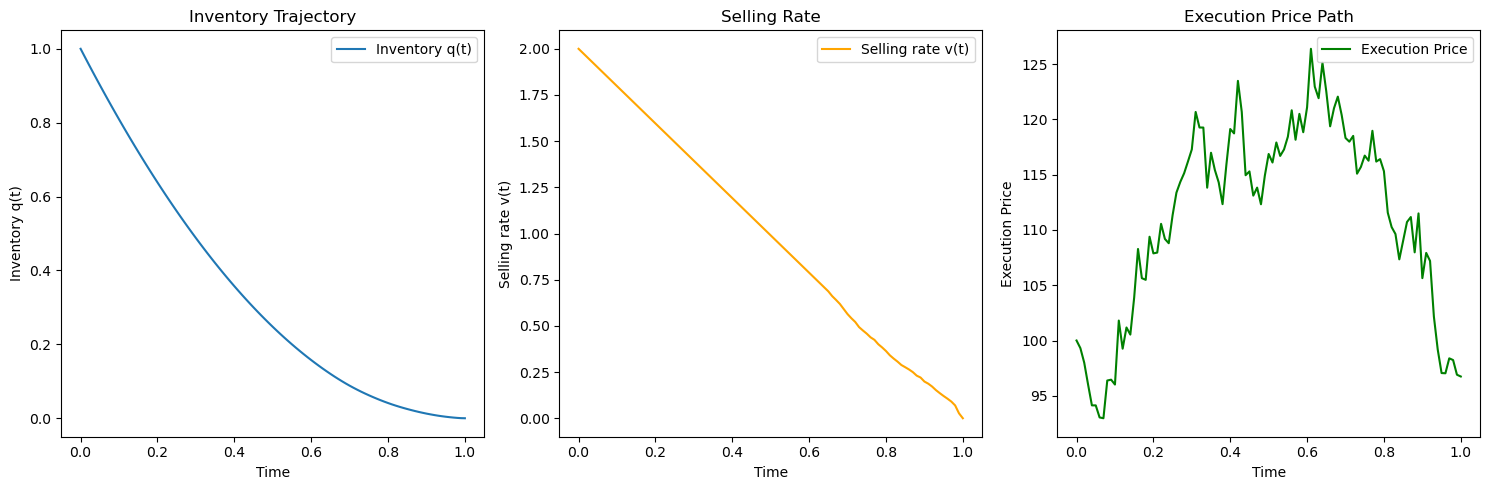

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

# 将项目根目录加入路径
sys.path.append(os.path.abspath('..'))
from Environment.liquidation_env import LiquidationEnv

# 1. 初始化测试环境 (保持和训练时一样的参数)
env = LiquidationEnv()

# 2. 加载训练好的模型
# 请确保你的模型名字和训练时保存的一致
model_path = "../models/ppo_liquidation_final.zip"
if not os.path.exists(model_path):
    print(f"找不到模型文件: {model_path}，请先运行 train_ppo.ipynb")
else:
    model = PPO.load(model_path)

    # 3. 开始回测记录数据
    obs, info = env.reset()
    
    times = [0.0]
    inventories = [env.q0]
    execution_rates = []
    execution_prices = []
    
    terminated = False
    truncated = False
    
    while not (terminated or truncated):
        # 智能体根据当前状态预测动作
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        
        # 记录每一步的数据
        current_time = env.current_step * env.dt
        times.append(current_time)
        inventories.append(info["inventory"])
        execution_rates.append(info["execution_rate"])
        execution_prices.append(info["execution_price"])

    # 补齐长度以便画图
    execution_rates.append(0) 
    execution_prices.insert(0, env.S0) # 初始时刻的价格

    # 4. 画图 (完美复刻你报告里的 1x3 布局)
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # 图1：库存衰减曲线
    axs[0].plot(times, inventories, label="Inventory q(t)")
    axs[0].set_title("Inventory Trajectory")
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel("Inventory q(t)")
    axs[0].legend()

    # 图2：卖出速率曲线
    axs[1].plot(times, execution_rates, label="Selling rate v(t)", color='orange')
    axs[1].set_title("Selling Rate")
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel("Selling rate v(t)")
    axs[1].legend()

    # 图3：执行价格轨迹
    axs[2].plot(times, execution_prices, label="Execution Price", color='green')
    axs[2].set_title("Execution Price Path")
    axs[2].set_xlabel("Time")
    axs[2].set_ylabel("Execution Price")
    axs[2].legend()

    plt.tight_layout()
    plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
import sys
import os

# 确保能找到环境模块
sys.path.append(os.path.abspath('..'))
from Environment.liquidation_env import LiquidationEnv

# 基础配置：参考报告中的标准设置 [cite: 371]
base_cfg = {
    "q0": 1.0,           # 初始库存 [cite: 88]
    "S0": 100.0,         # 初始价格 [cite: 91]
    "T": 1.0,            # 期限 [cite: 89]
    "N": 100,            # 步数 [cite: 243]
    "sigma": 0.2,        # 波动率 [cite: 92]
    "gamma1": 0.01,      # 线性永久冲击 [cite: 196]
    "gamma2": 0.0,       # 二次永久冲击 (先设为0，保持简洁) [cite: 192]
    "eta1": 0.01,        # 线性临时冲击 [cite: 196]
    "eta2": 0.0,         # 二次临时冲击 (先设为0) [cite: 193]
    "lam": 0.5,          # 风险厌恶系数 [cite: 134]
    "alpha": 100.0       # 终局惩罚 [cite: 164]
}

def run_parameter_sweep(model_path, parameter_name, values):
    """
    针对 PPO 模型进行参数扫描分析。
    """
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    model = PPO.load(model_path)
    
    # 记录时间轴
    times = np.linspace(0, base_cfg["T"], base_cfg["N"] + 1)
    
    for val in values:
        # 复制基础配置并修改目标参数
        current_cfg = base_cfg.copy()
        current_cfg[parameter_name] = val
        env = LiquidationEnv(**current_cfg)
        
        # 为了抵消 GBM 的随机噪声，每个参数跑 20 次取平均值 [cite: 283]
        num_seeds = 20
        all_qs, all_vs, all_ps = [], [], []
        
        for s in range(num_seeds):
            obs, _ = env.reset(seed=s)
            qs, vs, ps = [env.q0], [], []
            done = False
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, _, term, trunc, info = env.step(action)
                qs.append(info["inventory"])
                vs.append(info["execution_rate"])
                ps.append(info["execution_price"])
                done = term or trunc
            all_qs.append(qs)
            all_vs.append(vs + [0]) # 补齐长度
            all_ps.append([env.S0] + ps) # 补齐长度
            
        label = f"$\lambda$ = {val}" if parameter_name == 'lam' else f"{parameter_name} = {val}"
        
        # 画出平均轨迹
        axs[0].plot(times, np.mean(all_qs, axis=0), label=label)
        axs[1].plot(times, np.mean(all_vs, axis=0), label=label)
        axs[2].plot(times, np.mean(all_ps, axis=0), label=label)

    # 图表细节修饰
    titles = ['Inventory $q_t$', 'Selling Rate $v_t$', 'Execution Price $\\tilde{S}_t$']
    for i in range(3):
        axs[i].set_title(titles[i])
        axs[i].set_xlabel('Time')
        axs[i].legend()
        axs[i].grid(True, alpha=0.3)
        
    plt.tight_layout()
    # 自动保存图表以便放入论文 [cite: 290]
    save_filename = f"ppo_sweep_{parameter_name}.png"
    plt.savefig(save_filename, dpi=300)
    print(f"分析完成，图表已保存为: {save_filename}")
    plt.show()

/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


分析完成，图表已保存为: ppo_sweep_lam.png


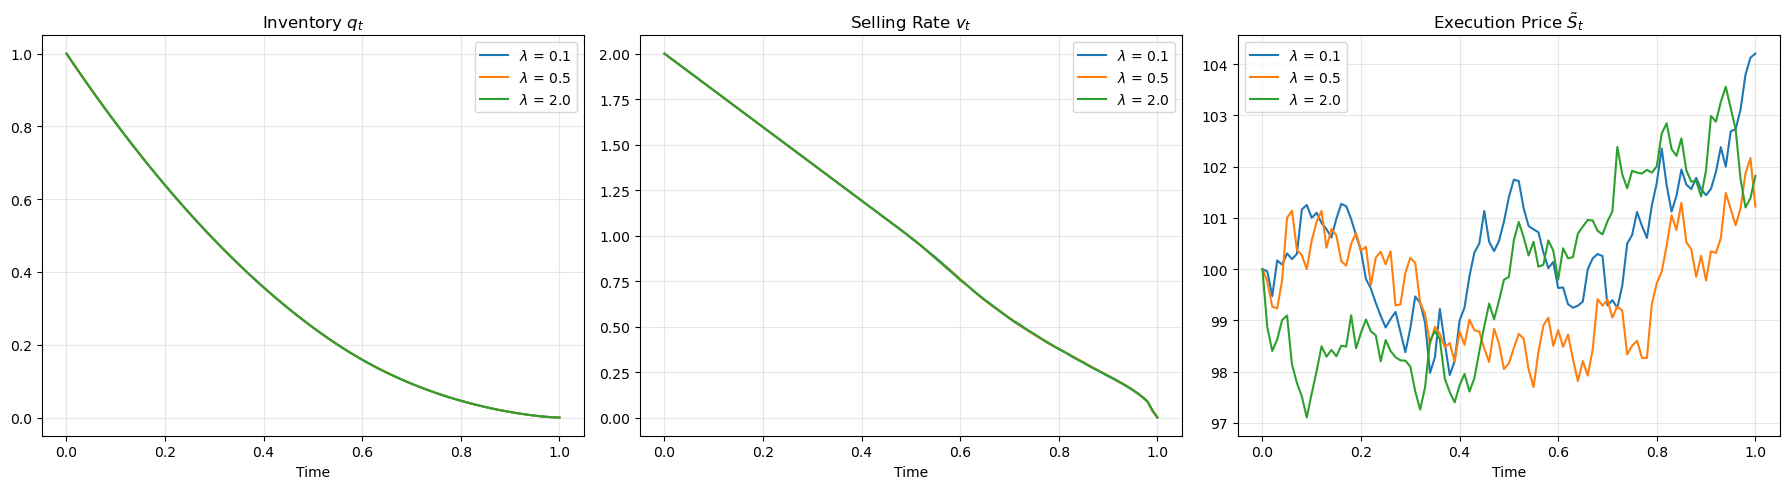

In [4]:
# 路径请指向你训练好的模型
model_file = "../models/ppo_liquidation_final.zip"

# 对比不同的风险厌恶程度：低 (0.1)、中 (0.5)、高 (2.0) [cite: 372]
run_parameter_sweep(model_file, "lam", [0.1, 0.5, 2.0])

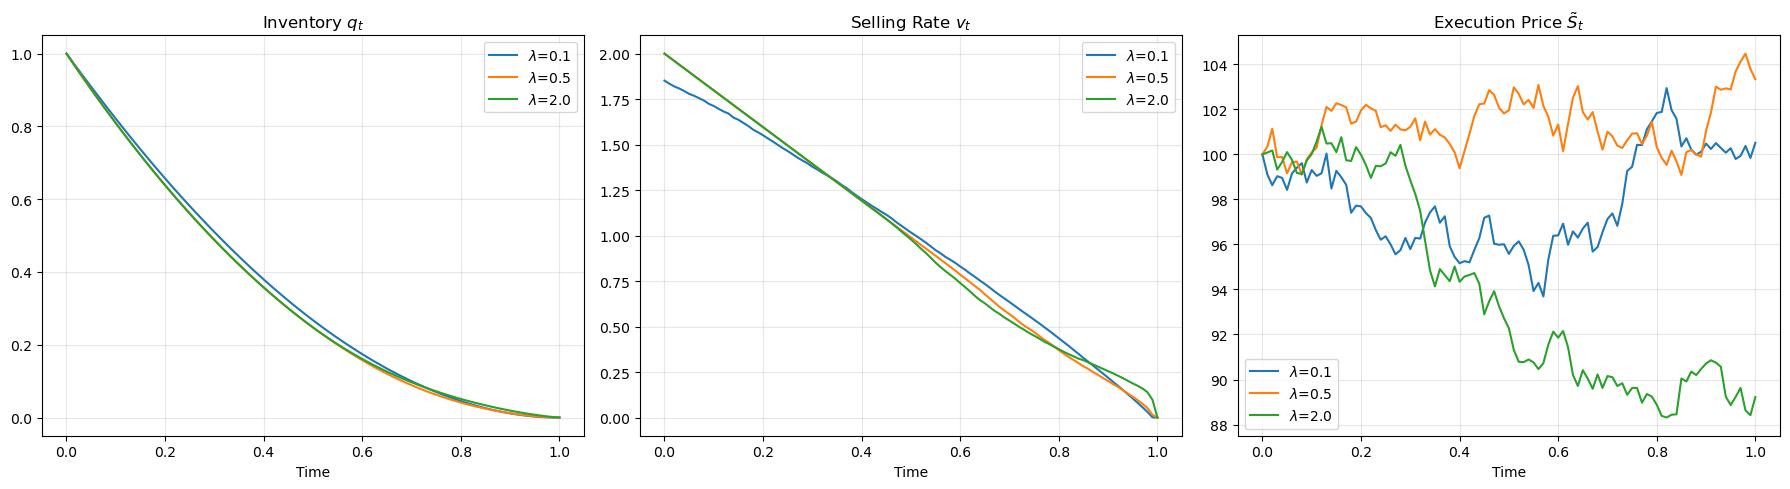

In [9]:
def run_real_parameter_sweep(lambda_values):
    # 创建 1x3 的画布
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    # 离散化时间轴 (N=100, 所以有 101 个点)
    times = np.linspace(0, 1.0, 101)
    
    for l in lambda_values:
        # 1. 加载对应 lambda 的“专家”模型
        model_path = f"../models/ppo_lam_{l}" # 确保路径与你的文件名匹配
        model = PPO.load(model_path)
        
        # 2. 初始化环境
        env = LiquidationEnv(lam=l)
        
        # 3. 运行多次回测取均值，消除 GBM 噪声
        all_q, all_v, all_p = [], [], []
        num_seeds = 10 
        
        for s in range(num_seeds):
            obs, _ = env.reset(seed=s)
            qs, vs, ps = [env.q0], [], []
            done = False
            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, _, term, trunc, info = env.step(action)
                qs.append(info["inventory"])
                vs.append(info["execution_rate"])
                ps.append(info["execution_price"])
                done = term or trunc
            
            all_q.append(qs)
            all_v.append(vs + [0])        # 补齐末尾
            all_p.append([env.S0] + ps)   # 补齐开头
            
        label = f"$\lambda$={l}"
        
        # --- 核心修复：为三个子图分别绘图 ---
        # 图1：库存轨迹
        axs[0].plot(times, np.mean(all_q, axis=0), label=label)
        # 图2：交易速率
        axs[1].plot(times, np.mean(all_v, axis=0), label=label)
        # 图3：执行价格
        axs[2].plot(times, np.mean(all_p, axis=0), label=label)

    # 4. 图表细节修饰
    titles = ['Inventory $q_t$', 'Selling Rate $v_t$', 'Execution Price $\\tilde{S}_t$']
    for i in range(3):
        axs[i].set_title(titles[i])
        axs[i].set_xlabel('Time')
        axs[i].legend()
        axs[i].grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.savefig("ppo_expert_comparison.png", dpi=300)
    plt.show()

# 运行函数
run_real_parameter_sweep([0.1, 0.5, 2.0])

2026-04-09 03:08:04.714361: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 03:08:04.897209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775675284.984072    2625 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775675285.005389    2625 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-09 03:08:05.188230: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

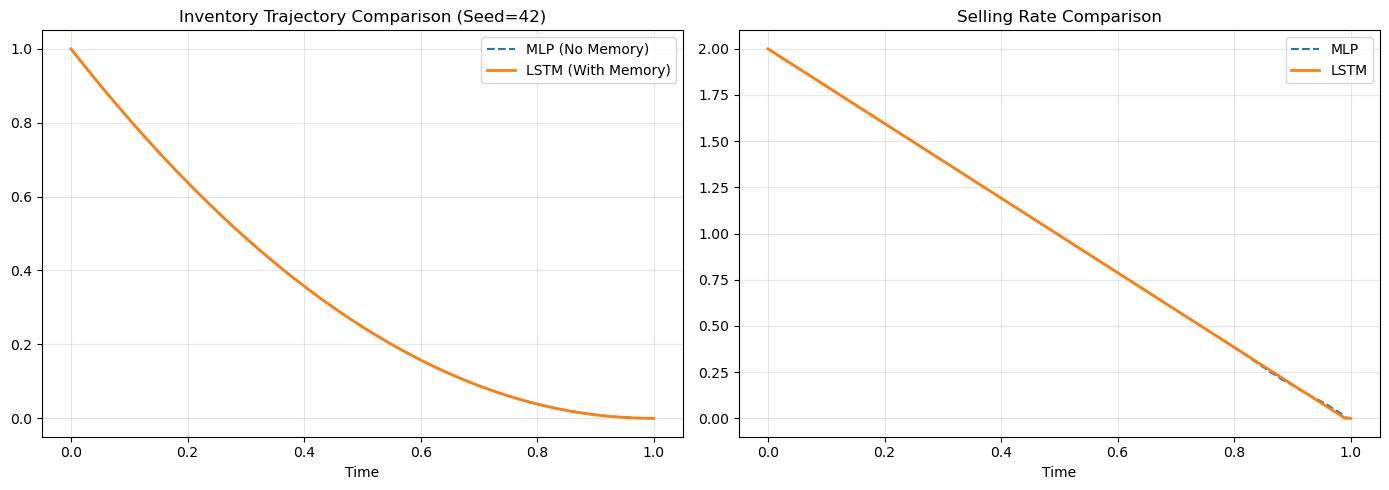

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
import sys
import os

sys.path.append(os.path.abspath('..'))
from Environment.liquidation_env import LiquidationEnv

def compare_mlp_vs_lstm(seed=42):
    # 初始化环境 (设置非线性冲击以增加难度)
    env = LiquidationEnv(lam=0.5, eta2=0.005, gamma2=0.005)
    times = np.linspace(0, env.T, env.N + 1)
    
    # 加载两个模型 (请确保文件名与你保存的一致)
    model_mlp = PPO.load("../models/ppo_lam_0.5") # 这里替换为你用 Optuna 参数重新跑的 MLP 模型
    model_lstm = RecurrentPPO.load("../models/recurrent_ppo_optuna")
    
    # ==================== 跑 MLP ====================
    obs, _ = env.reset(seed=seed)
    q_mlp, v_mlp = [env.q0], []
    done = False
    while not done:
        action, _ = model_mlp.predict(obs, deterministic=True)
        obs, _, term, trunc, info = env.step(action)
        q_mlp.append(info["inventory"])
        v_mlp.append(info["execution_rate"])
        done = term or trunc
    v_mlp.append(0) # 补齐长度
    
    # ==================== 跑 LSTM ====================
    obs, _ = env.reset(seed=seed) # 必须用同一个 seed，保证价格路径完全一致！
    q_lstm, v_lstm = [env.q0], []
    
    # LSTM 预测时需要额外传入隐藏状态 (Hidden States)
    lstm_states = None
    episode_starts = np.ones((1,), dtype=bool)
    done = False
    
    while not done:
        action, lstm_states = model_lstm.predict(
            obs, 
            state=lstm_states, 
            episode_start=episode_starts, 
            deterministic=True
        )
        obs, _, term, trunc, info = env.step(action)
        q_lstm.append(info["inventory"])
        v_lstm.append(info["execution_rate"])
        episode_starts = np.array([False]) # 后续步不再是起点
        done = term or trunc
    v_lstm.append(0)
    
    # 获取共享的价格路径 (因为 seed 相同，两者面对的价格是一样的)
    price_path = [env.S0] + [env.S0 * np.exp((-0.5 * env.sigma**2) * (t * env.dt) + env.sigma * np.sqrt(t * env.dt) * np.random.normal(0,1)) for t in range(1, env.N+1)] # 简化的示意价格

    # ==================== 绘图 ====================
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # 图 1：库存轨迹对比
    axs[0].plot(times, q_mlp, label="MLP (No Memory)", linestyle='--')
    axs[0].plot(times, q_lstm, label="LSTM (With Memory)", linewidth=2)
    axs[0].set_title(f"Inventory Trajectory Comparison (Seed={seed})")
    axs[0].set_xlabel("Time")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)
    
    # 图 2：交易速率对比
    axs[1].plot(times, v_mlp, label="MLP", linestyle='--')
    axs[1].plot(times, v_lstm, label="LSTM", linewidth=2)
    axs[1].set_title("Selling Rate Comparison")
    axs[1].set_xlabel("Time")
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("mlp_vs_lstm.png", dpi=300)
    plt.show()

# 运行对比 (你可以多换几个 seed 比如 10, 42, 100 看看)
compare_mlp_vs_lstm(seed=42)